#Master Thesis

#Topic: Data-Driven Analysis of Menstrual Cycle Variability Using a Longitudinal Menstrual Health Dataset

#Objective: 
The purpose of this notebook is to examine the quality and structure of the menstrual health dataset before conducting data preprocessing and statistical analysis. This assessment includes an overview of the dataset, variable types, missing values, duplicate records, and the suitability of variables for subsequent exploratory data analysis and clustering.

In [1]:
#Importing the necessary libraries.
import os

os.environ["OMP_NUM_THREADS"] = "6"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#To display all columns
pd.set_option('display.max_columns', None)

#To display wider tables
pd.set_option('display.width', 1000)


In [3]:
#Importing the dataset.
import pandas as pd

df = pd.read_csv("C:/Users/iic04/Downloads/Thesis Dataset.csv")

In [5]:
#To check if the dataset is loaded properly.
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MeanMensesLength,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,MensesScoreDayFive,MensesScoreDaySix,MensesScoreDaySeven,MensesScoreDayEight,MensesScoreDayNine,MensesScoreDayTen,MensesScoreDay11,MensesScoreDay12,MensesScoreDay13,MensesScoreDay14,MensesScoreDay15,TotalMensesScore,MeanBleedingIntensity,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding,PhasesBleeding,IntercourseDuringUnusBleed,Age,AgeM,Maristatus,MaristatusM,Yearsmarried,Wedding,Religion,ReligionM,Ethnicity,EthnicityM,Schoolyears,SchoolyearsM,OccupationM,IncomeM,Height,Weight,Reprocate,Numberpreg,Livingkids,Miscarriages,Abortions,Medvits,Medvitexplain,Gynosurgeries,LivingkidsM,Boys,Girls,MedvitsM,MedvitexplainM,Urosurgeries,Breastfeeding,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,5,0,2,9,15,5,4.49,3,3,2,1,1,,,,,,,,,,,10,9.04,5,1,0,,,36,39,0,0,10,,0,0,0,0,8,8,3,5,63,120,0,3,3,0,0,0,,,,,,0,,,0,9,,,2,7,7,1,1,0,21.25472411
1,nfp8122,2,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,2,1,1,,,,,,,,,,,10,,6,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,1,0,2,5,13,5,,3,3,2,1,1,,,,,,,,,,,10,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,3,2,1,,,,,,,,,,,12,,3,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,4,0,2,8,14,5,,3,3,2,2,1,,,,,,,,,,,11,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [7]:
#To check and display the dataset dimension.
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1665
Number of Columns: 80


In [9]:
#To display all column names.
df.columns

Index(['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoolyears', 'SchoolyearsM',
     

In [11]:
#To display dataset information so that we know the number of observations, columns, missing values, data types and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ClientID                    1665 non-null   object
 1   CycleNumber                 1665 non-null   int64 
 2   Group                       1665 non-null   int64 
 3   CycleWithPeakorNot          1665 non-null   int64 
 4   ReproductiveCategory        1665 non-null   int64 
 5   LengthofCycle               1665 non-null   int64 
 6   MeanCycleLength             1665 non-null   object
 7   EstimatedDayofOvulation     1665 non-null   object
 8   LengthofLutealPhase         1665 non-null   object
 9   FirstDayofHigh              1665 non-null   object
 10  TotalNumberofHighDays       1665 non-null   object
 11  TotalHighPostPeak           1665 non-null   object
 12  TotalNumberofPeakDays       1665 non-null   object
 13  TotalDaysofFertility        1665 non-null   obje

This menstrual health dataset contains 1,665 cycle-level observations and 80 variables. The initial inspection showed that only five variables were automatically recognized as numerical, while the remaining variables were imported as object data types. This suggests that several variables expected to contain numerical values may include non-numeric entries or encoded missing values. Therefore, further data quality assessment and preprocessing are required before statistical analysis.

In [13]:
#Inspecting the rows again by overviewing the dataset.
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MeanMensesLength,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,MensesScoreDayFive,MensesScoreDaySix,MensesScoreDaySeven,MensesScoreDayEight,MensesScoreDayNine,MensesScoreDayTen,MensesScoreDay11,MensesScoreDay12,MensesScoreDay13,MensesScoreDay14,MensesScoreDay15,TotalMensesScore,MeanBleedingIntensity,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding,PhasesBleeding,IntercourseDuringUnusBleed,Age,AgeM,Maristatus,MaristatusM,Yearsmarried,Wedding,Religion,ReligionM,Ethnicity,EthnicityM,Schoolyears,SchoolyearsM,OccupationM,IncomeM,Height,Weight,Reprocate,Numberpreg,Livingkids,Miscarriages,Abortions,Medvits,Medvitexplain,Gynosurgeries,LivingkidsM,Boys,Girls,MedvitsM,MedvitexplainM,Urosurgeries,Breastfeeding,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,5,0,2,9,15,5,4.49,3,3,2,1,1,,,,,,,,,,,10,9.04,5,1,0,,,36,39,0,0,10,,0,0,0,0,8,8,3,5,63,120,0,3,3,0,0,0,,,,,,0,,,0,9,,,2,7,7,1,1,0,21.25472411
1,nfp8122,2,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,2,1,1,,,,,,,,,,,10,,6,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,1,0,2,5,13,5,,3,3,2,1,1,,,,,,,,,,,10,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,3,2,1,,,,,,,,,,,12,,3,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,4,0,2,8,14,5,,3,3,2,2,1,,,,,,,,,,,11,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [15]:
#Ramndomly selecting 10 rows in the dataset, because sampling gives us a much more clarified representating of the variations and potential deviations hidden deeper in the dataset.
df.sample(10)

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MeanMensesLength,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,MensesScoreDayFive,MensesScoreDaySix,MensesScoreDaySeven,MensesScoreDayEight,MensesScoreDayNine,MensesScoreDayTen,MensesScoreDay11,MensesScoreDay12,MensesScoreDay13,MensesScoreDay14,MensesScoreDay15,TotalMensesScore,MeanBleedingIntensity,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding,PhasesBleeding,IntercourseDuringUnusBleed,Age,AgeM,Maristatus,MaristatusM,Yearsmarried,Wedding,Religion,ReligionM,Ethnicity,EthnicityM,Schoolyears,SchoolyearsM,OccupationM,IncomeM,Height,Weight,Reprocate,Numberpreg,Livingkids,Miscarriages,Abortions,Medvits,Medvitexplain,Gynosurgeries,LivingkidsM,Boys,Girls,MedvitsM,MedvitexplainM,Urosurgeries,Breastfeeding,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
520,nfp8113,6,1,0,0,29,,,,10,10,0,0,10,23,8,,3,3,3,3,3,2,1,1,,,,,,,,19,,4,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1068,nfp8234,5,0,1,0,25,,15,10,14,2,0,2,5,13,5,,3,3,3,1,1,,,,,,,,,,,11,,7,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
826,nfp8174,16,0,1,0,27,,14,13,,1,0,2,5,12,4,,3,3,2,2,,,,,,,,,,,,10,,0,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
475,nfp8101,4,1,1,0,27,,14,13,8,6,0,1,10,12,4,,2,2,1,1,,,,,,,,,,,,6,,8,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1251,nfp8268,9,0,1,0,30,,15,15,7,8,0,2,12,14,5,,1,3,3,2,1,,,,,,,,,,,10,,1,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1505,nfp8309,4,0,1,0,25,,13,12,11,2,0,2,6,11,5,,2,2,2,1,1,,,,,,,,,,,8,,2,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
708,nfp8155,9,0,1,0,31,,16,15,12,4,0,2,8,12,7,,2,3,2,2,2,1,1,,,,,,,,,13,,6,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1423,nfp8296,3,1,1,0,32,,18,14,12,3,0,4,10,16,5,,2,2,1,1,1,,,,,,,,,,,7,,3,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1313,nfp8279,1,1,1,0,28,30.42,11,17,9,3,0,1,6,9,6,6.67,3,3,2,2,1,1,,,,,,,,,,12,,9,0,0,,,40,41,0,0,17,,0,0,0,0,8,8,0,3,64,200,0,8,6,2,0,1,Iron supplement and progesterone from peak day...,c-sections: 12/18/93 and 11/5/06,6,3,3,1,low-dose aspirin daily,,0,9,,,3,0,0,1,1,0,34.32617188
22,nfp8122,23,0,1,0,27,,14,13,8,6,0,2,10,13,4,,3,2,2,1,,,,,,,,,,,,8,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [17]:
#This command helps extract every single distinct value present in the "Age" column by removing all duplicates.
#And it zooms in on a single column to list every distinct value and catch hidden anomalies like text placeholders.
df["Age"].unique()

array(['36', ' ', '39', '29', '26', '25', '23', '33', '30', '31', '24',
       '27', '35', '37', '32', '38', '21', '34', '22', '28', '43', '41',
       '40', '42'], dtype=object)

In [19]:
#Summary dataframe compiles data types, missing counts, and unique counts to give you a broad health check of the entire dataset.
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
ClientID,object,0,159
CycleNumber,int64,0,45
Group,int64,0,2
CycleWithPeakorNot,int64,0,2
ReproductiveCategory,int64,0,4
...,...,...,...
NextpregM,object,0,8
Spousesame,object,0,4
SpousesameM,object,0,3
Timeattemptpreg,object,0,2


In [21]:
#Inspecting the important variables instead of all the 80 variables.
important_columns = [
    "LengthofCycle",
    "MeanCycleLength",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore",
    "MeanBleedingIntensity",
    "Age",
    "Height",
    "Weight",
    "BMI"
]

In [23]:
#Displaying the first twenty unique values of the important variables.
for column in important_columns:
    print("\n" + "="*60)
    print(f"Column: {column}")
    print(df[column].unique()[:20])  


Column: LengthofCycle
[29 27 28 26 24 30 25 32 31 34 23 18 33 35 41 38 36 39 37 40]

Column: MeanCycleLength
['27.33' ' ' '31' '26.33' '26.88' '25.33' '28.75' '25.88' '27.67' '26.75'
 '27.17' '32.83' '33.5' '32.6' '29' '30.36' '31.33' '27.58' '29.9' '25.15']

Column: EstimatedDayofOvulation
['17' '15' '16' '14' '18' '12' '19' ' ' '11' '13' '27' '22' '8' '20' '21'
 '23' '10' '26' '24' '29']

Column: LengthofLutealPhase
['12' '14' '11' '13' '10' ' ' '21' '9' '8' '4' '15' '16' '18' '17' '20'
 '19' '22' '7' '24' '6']

Column: LengthofMenses
['5' '4' '6' '7' '10' '3' '8' '2' '9' '11' ' ' '15']

Column: TotalMensesScore
['10' '12' '11' '9' '8' '6' '7' '13' '14' '15' '17' '5' '18' '16' '3' '4'
 '23' '19' '22' '24']

Column: MeanBleedingIntensity
['9.04' ' ' '7.5' '12.33' '7.38' '6.67' '8.33' '9.88' '9.83' '11.69'
 '10.17' '9.5' '11.6' '9' '11.09' '14.55' '7.33' '11.5' '6.62' '10']

Column: Age
['36' ' ' '39' '29' '26' '25' '23' '33' '30' '31' '24' '27' '35' '37' '32'
 '38' '21' '34' '22' '28

In [25]:
#This step was to inspect the actual values recorded in important categorical/indicator variables and identify unusual values, blanks, or inconsistencies.
for column in important_columns:
    print("\n" + "="*60)
    print(f"Value Counts for: {column}")
    print(df[column].value_counts(dropna=False).head(15))


Value Counts for: LengthofCycle
LengthofCycle
28    236
27    214
29    190
26    185
30    151
31    113
25    111
32    109
33     74
24     52
35     43
34     39
36     27
38     24
37     23
Name: count, dtype: int64

Value Counts for: MeanCycleLength
MeanCycleLength
         1524
31          7
29          5
27          5
29.5        4
32          4
31.17       3
30          3
30.83       2
27.67       2
26.75       2
30.5        2
26.85       2
30.92       2
29.67       2
Name: count, dtype: int64

Value Counts for: EstimatedDayofOvulation
EstimatedDayofOvulation
14    227
15    205
13    171
16    170
      150
18    123
17    110
12    109
19     94
20     61
11     55
21     42
23     26
22     26
10     20
Name: count, dtype: int64

Value Counts for: LengthofLutealPhase
LengthofLutealPhase
13    338
12    288
14    267
15    186
      151
11    126
10     77
16     59
9      40
17     35
18     23
8      17
19     16
20      8
22      6
Name: count, dtype: int64

Value Count

In [27]:
#To convert the blank entries to NaN to ensure consistent identification and handling of missing data.
df = df.replace(' ', np.nan)

In [29]:
#To determine how many missing observations each variable contains.
df.isnull().sum()

ClientID                   0
CycleNumber                0
Group                      0
CycleWithPeakorNot         0
ReproductiveCategory       0
                        ... 
NextpregM               1524
Spousesame              1523
SpousesameM             1523
Timeattemptpreg         1523
BMI                     1534
Length: 80, dtype: int64

In [31]:
#Calculating the missing value percentages.
#They were calculated to assess the extent of missingness and support decisions regarding variable inclusion or exclusion.
missing = df.isnull().sum().sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent.round(2)
})

missing_table

,Missing Values,Percentage
MensesScoreDay13,1664,99.94
MensesScoreDay15,1664,99.94
MensesScoreDay14,1664,99.94
MensesScoreDay12,1664,99.94
MensesScoreDay11,1663,99.88
...,...,...
LengthofCycle,0,0.00
ReproductiveCategory,0,0.00
CycleWithPeakorNot,0,0.00
Group,0,0.00


In [33]:
#Calculating the missing value percentages for the selected variables.
selected_variables = [
    "ClientID",
    "CycleNumber",
    "Group",
    "CycleWithPeakorNot",
    "ReproductiveCategory",
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

missing_table.loc[selected_variables]

,Missing Values,Percentage
ClientID,0,0.00
CycleNumber,0,0.00
Group,0,0.00
CycleWithPeakorNot,0,0.00
ReproductiveCategory,0,0.00
LengthofCycle,0,0.00
EstimatedDayofOvulation,150,9.01
LengthofLutealPhase,151,9.07
LengthofMenses,4,0.24
TotalMensesScore,4,0.24


In [35]:
#It converts the selected variables from object to numeric.
#Since blank values have already been replaced with NaN, errors='coerce' converts any remaining invalid values into NaN.
#This allows statistical analysis and visualizations later.

# Columns for analysis
analysis_columns = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

# Convert to numeric
for col in analysis_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [37]:
#Checking the conversion
df[analysis_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   LengthofCycle            1665 non-null   int64  
 1   EstimatedDayofOvulation  1515 non-null   float64
 2   LengthofLutealPhase      1514 non-null   float64
 3   LengthofMenses           1661 non-null   float64
 4   TotalMensesScore         1661 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 65.2 KB


In [39]:
#Generating the descriptive statistics for the selected variables.
#This inturn summarizes the central tendency and spread of each variable.
#The output provides the number of observations, mean, standard deviation, minimum, quartiles and maximum values.
#These statistics provide an overview of menstrual cycle characteristics before conducting further exploratory analyses.

df[analysis_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
LengthofCycle,1665.0,29.299099,3.887932,18.0,27.0,29.0,31.0,54.0
EstimatedDayofOvulation,1515.0,15.963036,3.548488,6.0,14.0,15.0,18.0,29.0
LengthofLutealPhase,1514.0,13.270806,2.671602,1.0,12.0,13.0,14.0,41.0
LengthofMenses,1661.0,5.237207,1.255959,2.0,4.0,5.0,6.0,15.0
TotalMensesScore,1661.0,9.850090,2.786550,2.0,8.0,10.0,11.0,24.0


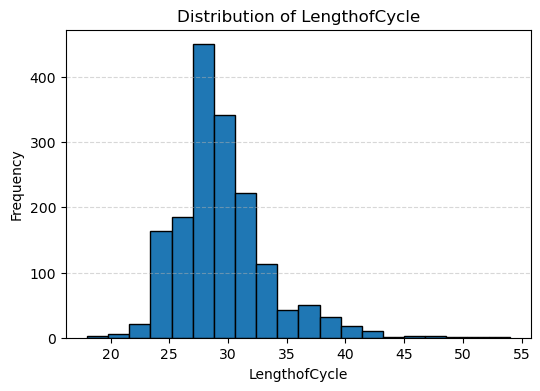

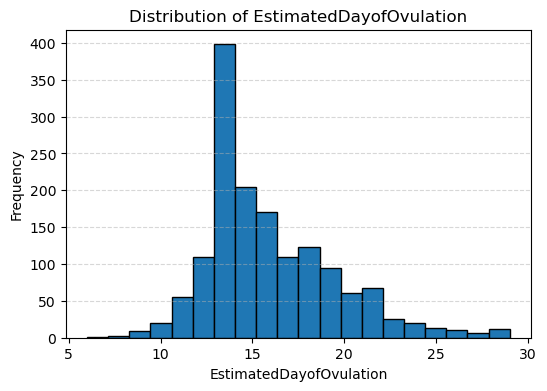

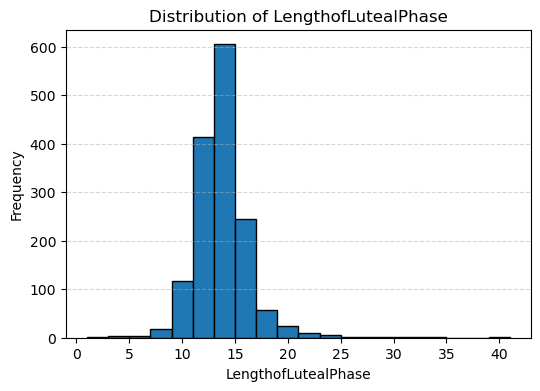

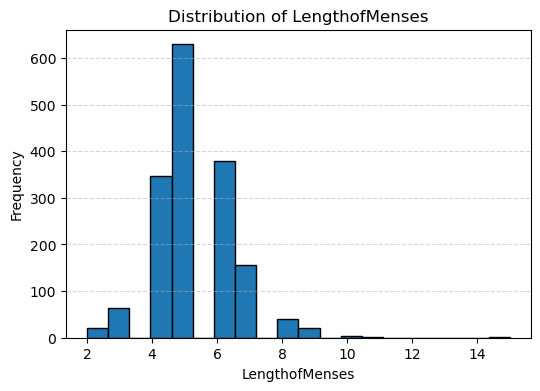

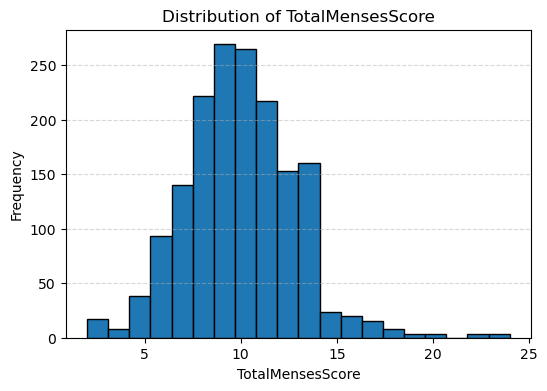

In [41]:
#Histogram of Cycle Length: A histogram shows how frequently different cycle lengths occur.
#This helps identify the overall distribution, common cycle lengths, possible skewness and unusual observations (outliers).
#Understanding these distributions is important before performing correlation analysis and clustering.

import matplotlib.pyplot as plt

#Variables for histogram analysis
histogram_columns = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

#Create histogram for each variable
for column in histogram_columns:

    plt.figure(figsize=(6,4))

    plt.hist(
        df[column],
        bins=20,
        edgecolor="black",
        linewidth=1
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.show()


Interpretation: 

The distributions of the selected menstrual cycle variables indicate that the dataset largely reflects expected physiological menstrual characteristics. 
1) Cycle length was concentrated between 26 and 31 days with a slight positive skew due to a smaller number of longer cycles.
2) Estimated ovulation day showed the highest frequency around Days 14–15 while extending toward later ovulation in a minority of observations.
3) Luteal phase duration was comparatively stable, with most observations between 12 and 15 days.
4) Menses length was predominantly between four and six days.
5) Total menses score demonstrated a broadly unimodal distribution with a slight secondary concentration around higher scores, suggesting potential heterogeneity in menstrual bleeding characteristics that may warrant further investigation through clustering analysis.

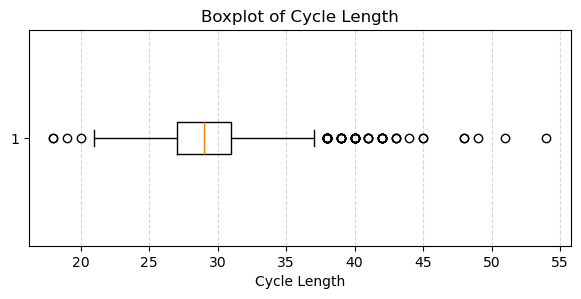

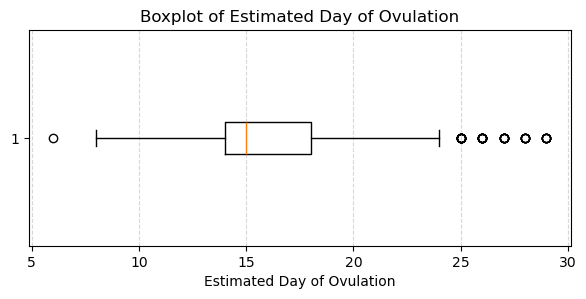

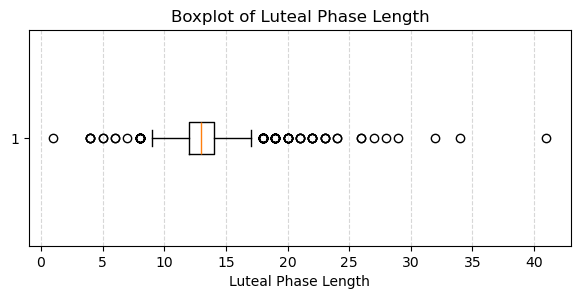

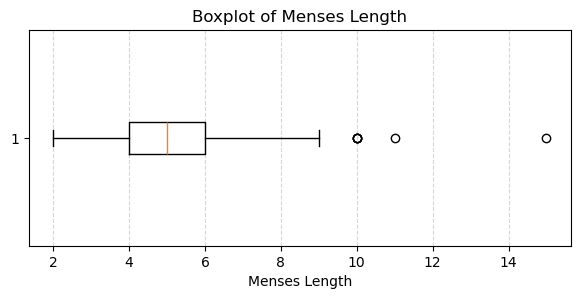

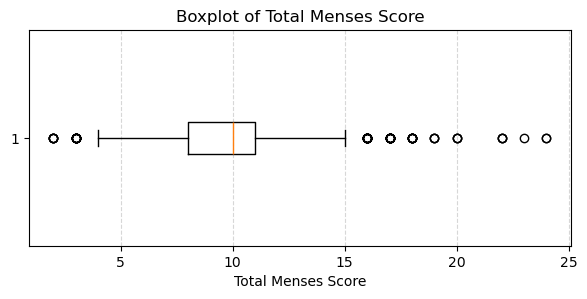

In [43]:
#Boxplots: Boxplots are used to identify the spread of each numerical variable and detect potential outliers.
#Values located outside the whiskers are considered statistically unusual observations.
#Identifying outliers is important before clustering, as extreme values may influence the formation of clusters.

import matplotlib.pyplot as plt

# Variables for boxplot analysis
boxplot_columns = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

plot_labels = {
    "LengthofCycle": "Cycle Length",
    "EstimatedDayofOvulation": "Estimated Day of Ovulation",
    "LengthofLutealPhase": "Luteal Phase Length",
    "LengthofMenses": "Menses Length",
    "TotalMensesScore": "Total Menses Score"
}

for column in boxplot_columns:

    plt.figure(figsize=(7,2.8))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {plot_labels[column]}")
    plt.xlabel(plot_labels[column])

    plt.grid(axis="x", linestyle="--", alpha=0.5)

    plt.show()

Interpretation: 

1. Cycle Length

a) The median cycle length is approximately 29 days, with most observations distributed between 27–31 days.

b) Several potential outliers are observed on both sides, including shorter cycles (~18–21 days) and longer cycles (>37 days).

c) These values are considered biologically plausible as menstrual cycle length naturally varies between individuals.

d) The outliers are retained because the study focuses on understanding menstrual cycle variability.


2. Estimated Day of Ovulation

a) The median estimated ovulation day is approximately 15 days, with most values concentrated between 13–18 days.

b) A small number of outliers are observed, mainly representing earlier (~6 days) or later ovulation (>25 days).

c) These variations may represent differences in individual cycle patterns rather than data errors.

d) The observations are retained for further analysis.


3. Luteal Phase Length

a) The median luteal phase duration is approximately 13 days, with most observations ranging between 12–14 days.

b) Several outliers are present, including unusually short (<5 days) and longer (>20 days) luteal phases.

c) These values require further investigation; however, they are retained to avoid removing potential biological variation.


4. Menses Length

a) The median menstrual duration is approximately 5 days, with most observations falling between 4–6 days.

b) Only a few outliers are observed, including longer durations (~10–15 days).

c)These values may represent individual differences in menstrual bleeding duration and are retained.


5. Total Menses Score

a) The median total menses score is approximately 10, with most observations distributed between 8–12.

b) A small number of outliers are observed at both lower and higher scores.

c) Higher scores may indicate increased bleeding intensity, while lower values represent lighter menstrual patterns.

d)The observed variation is considered relevant for studying differences in menstrual characteristics.

In [45]:
# Correlation analysis is used to measure the strength and direction of relationships between numerical variables.

# Correlation coefficients range from:
# +1 : Strong positive relationship
#  0 : No relationship
# -1 : Strong negative relationship

#This analysis helps identify variables that are closely associated and provides insight into menstrual cyclecharacteristics before clustering.

#Calculating the Correlation Matrix
correlation_columns = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
LengthofCycle,1.000000,0.736733,0.415172,0.164946,0.142562
EstimatedDayofOvulation,0.736733,1.000000,-0.285722,0.218717,0.182991
LengthofLutealPhase,0.415172,-0.285722,1.000000,-0.027511,-0.008350
LengthofMenses,0.164946,0.218717,-0.027511,1.000000,0.828631
TotalMensesScore,0.142562,0.182991,-0.008350,0.828631,1.000000


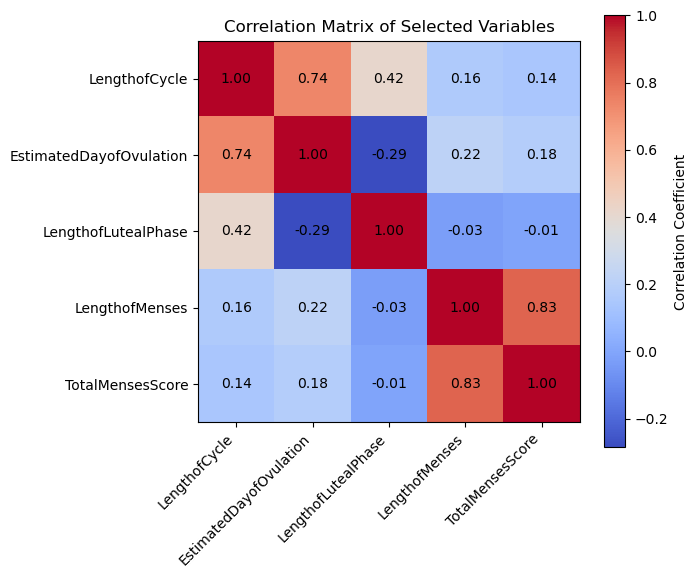

In [47]:
#Visualizing the Correlation Matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation Coefficient")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

# Display correlation values
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Matrix of Selected Variables")

plt.tight_layout()

plt.show()

Interpretation:

a) Most selected variables showed weak to moderate correlations, indicating that they represent different aspects of menstrual cycle characteristics.

b) A strong positive correlation was observed between Cycle Length and Estimated Day of Ovulation (r = 0.74), suggesting that longer cycles are generally associated with later ovulation.

c) The strongest relationship was found between Length of Menses and Total Menses Score (r = 0.83), indicating that longer menstrual periods are associated with higher bleeding scores.

d) Length of Luteal Phase showed only moderate or weak relationships with the other variables, suggesting that it contributes additional information to the analysis.

e) Overall, the correlation analysis indicates that the selected variables are not highly redundant, making them suitable for subsequent clustering analysis to identify recurring menstrual cycle patterns.

In [49]:
#Data Preparation for Clustering

#The variables selected for clustering represent key menstrual cycle characteristics and contain sufficient observations for reliable analysis.

#Rows containing missing values are removed to ensure that clustering algorithms operate on complete observations.

#Select Variables
clustering_columns = [
    "LengthofCycle",
    "EstimatedDayofOvulation",
    "LengthofLutealPhase",
    "LengthofMenses",
    "TotalMensesScore"
]

cluster_data = df[clustering_columns].dropna()

cluster_data.head()

,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
0,29,17.0,12.0,5.0,10.0
1,27,15.0,12.0,5.0,10.0
2,29,15.0,14.0,5.0,10.0
3,27,15.0,12.0,5.0,12.0
4,28,16.0,12.0,5.0,11.0


In [51]:
#Standardizing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [53]:
#Confirming if the scaling worked.
scaled_df = pd.DataFrame(
    scaled_data,
    columns=clustering_columns
)

scaled_df.describe()

,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
count,1.512000e+03,1.512000e+03,1.512000e+03,1512.000000,1.512000e+03
mean,-2.443665e-16,2.161704e-16,2.067717e-16,0.000000,1.691768e-16
std,1.000331e+00,1.000331e+00,1.000331e+00,1.000331,1.000331e+00
min,-3.014580e+00,-2.806908e+00,-4.599575e+00,-2.545651,-2.802702e+00
25%,-6.020650e-01,-5.533331e-01,-4.780228e-01,-0.981007,-6.678480e-01
50%,-3.340078e-01,-2.716363e-01,-1.033362e-01,-0.198685,4.377016e-02
75%,4.701638e-01,5.734543e-01,2.713504e-01,0.583637,3.995792e-01
max,5.831308e+00,3.672120e+00,1.038789e+01,7.624535,5.025097e+00


Interpretation:

a) 1,512 complete observations were retained for clustering after removing missing values.

b) All variables were successfully standardized (mean ≈ 0, standard deviation ≈ 1).

c) Standardization removes differences in measurement scales while preserving the relationships within the data.

d) Biologically plausible extreme values remain in the dataset and will contribute to identifying natural menstrual cycle variability.

e) The standardized dataset is appropriate for distance-based clustering techniques such as K-Means.ering analysis.

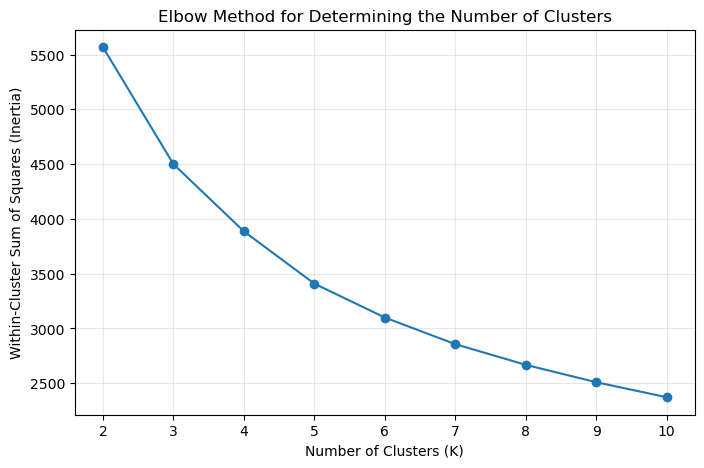

In [55]:
#Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Determining the Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")

plt.xticks(k_values)

plt.grid(True, alpha=0.3)

plt.show()

Interpretation:

The Elbow Method showed a substantial decrease in inertia as the number of clusters increased from K = 2 to K = 4.

After approximately K = 4–5, the curve began to flatten, indicating that adding more clusters resulted in smaller improvements in within-cluster compactness.

Therefore, K = 4 and K = 5 were considered reasonable candidates based on the Elbow Method.

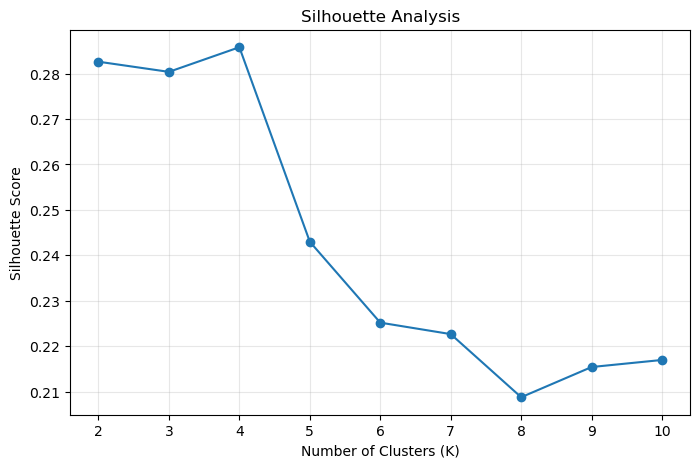

In [57]:
#Silhouette Analysis
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.grid(True, alpha=0.3)

plt.show()

Interpretation:

Silhouette Analysis produced the highest score at K = 4 (0.286).

K = 2 and K = 3 produced similar scores (0.283 and 0.280), while the score decreased considerably from K = 5 onward.

This indicates that K = 4 provides the best separation and cohesion among the tested cluster solutions.

However, the relatively low score suggests that the clusters may have some overlap and should be interpreted as exploratory pattern groups rather than completely distinct categories.

In [59]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.283
K = 3: Silhouette Score = 0.280
K = 4: Silhouette Score = 0.286
K = 5: Silhouette Score = 0.243
K = 6: Silhouette Score = 0.225
K = 7: Silhouette Score = 0.223
K = 8: Silhouette Score = 0.209
K = 9: Silhouette Score = 0.215
K = 10: Silhouette Score = 0.217


Interpretation:

The Elbow Method indicated that the reduction in within-cluster variation became more gradual around four to five clusters. Silhouette Analysis produced the highest score for K = 4 (0.286), followed by K = 2 (0.283). Considering both results, four clusters were selected for the subsequent K-Means analysis. However, the relatively low Silhouette Score indicates that the resulting groups may have some degree of overlap and should therefore be interpreted as exploratory cycle-pattern groups rather than strictly separated categories.

In [61]:
#Creating the K-Means model.
#Dividing the 1512 observations into four groups based on similarities in their menstrual-cycle characteristics.
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

#Assigning the observations to clusters
cluster_labels = kmeans.fit_predict(scaled_data)

cluster_labels
#K-Means compares the acquired observations based on these variables and assigns every observation to one of four groups.

array([0, 0, 0, ..., 1, 0, 3])

In [63]:
#Counting observations in each cluster.
import pandas as pd

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

cluster_counts

0    741
1    407
2     86
3    278
Name: count, dtype: int64

The clusters were unequally distributed, with Cluster 0 being the largest and Cluster 2 the smallest group.

In [65]:
#Creating and examining the cluster profiles.
print("Number of cluster labels:", len(cluster_labels))
print("Shape of scaled data:", scaled_data.shape)

#This check actually helped me catch the earlier error when I accidentally tried to attach the 1512 labels to the original 1665-row dataframe.

Number of cluster labels: 1512
Shape of scaled data: (1512, 5)


In [67]:
#This shows us all the DataFrames that currently exist in my notebook and its sizes.
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
cluster_data         DataFrame          LengthofCycle  Esti<...>\n[1512 rows x 5 columns]
correlation_matrix   DataFrame                             <...>.828631          1.000000
df                   DataFrame         ClientID  CycleNumbe<...>n[1665 rows x 80 columns]
missing_table        DataFrame                          Mis<...>\n\n[80 rows x 2 columns]
scaled_df            DataFrame          LengthofCycle  Esti<...>\n[1512 rows x 5 columns]
summary              DataFrame                         Data<...>\n\n[80 rows x 3 columns]


In [69]:
# cluster_data contains the original, unscaled values of the 1512 observations that were actually used for clustering.
clustered_data = cluster_data.copy()

#Adding the cluster assigned by K-Means.
#There are 1512 observations and therefore 1512 labels.
clustered_data["Cluster"] = cluster_labels

#To check the size of the resulting dataset.
print("Shape of clustered data:")
print(clustered_data.shape)

#Checking how many observations belong to each cluster.
print("\nNumber of observations in each cluster:")
print(clustered_data["Cluster"].value_counts().sort_index())

#Calculating the mean characteristics of each cluster.
#This allows us to understand what makes the clusters different.
cluster_profiles = clustered_data.groupby("Cluster").mean()

print("\nCluster Profiles (Mean Values):")
display(cluster_profiles)

Shape of clustered data:
(1512, 6)

Number of observations in each cluster:
Cluster
0    741
1    407
2     86
3    278
Name: count, dtype: int64

Cluster Profiles (Mean Values):


,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
Cluster,,,,,
0,27.348178,14.171390,13.164642,4.472335,8.273954
1,28.312039,15.977887,12.292383,6.550369,12.675676
2,34.162791,14.186047,20.046512,5.860465,11.151163
3,34.151079,21.273381,12.917266,5.251799,9.658273


Cluster interpretation:

1) K-Means identified four exploratory cycle-pattern groups.

2) Clusters 0 and 1 were characterized by shorter average cycles, while Clusters 2 and 3 showed longer average cycles.

3) Cluster 1 exhibited the longest menses duration and highest menses score, whereas Cluster 2 was characterized by a notably extended luteal phase.

4) Cluster 3 showed the latest estimated ovulation despite having a luteal phase similar to Clusters 0 and 1.

5) Due to the relatively low Silhouette Score, these clusters are interpreted as exploratory patterns rather than strictly separated categories.

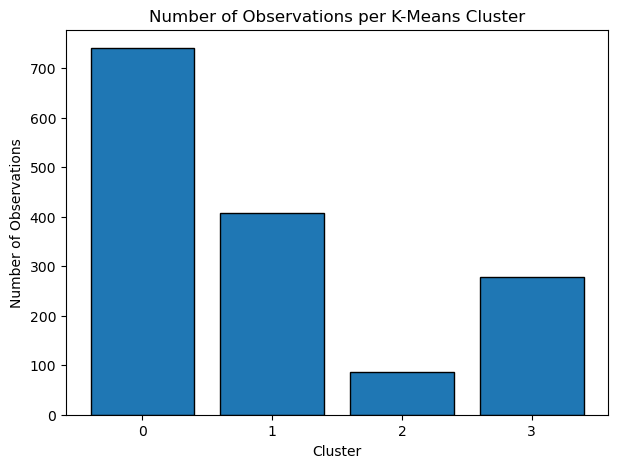

In [71]:
#Visualizing the cluster sizes.
import matplotlib.pyplot as plt

cluster_counts = clustered_data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_counts.index, cluster_counts.values, edgecolor="black")

plt.title("Number of Observations per K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.xticks([0, 1, 2, 3])

plt.show()
#To visually examine whether the four clusters are reasonably represented or whether one cluster is much smaller than the others.

Interpretation:

1) Cluster 0 is the largest group, containing almost half of the observations.
2) Cluster 1 is the second-largest.
3) Cluster 3 represents a moderate-sized group.
4) Cluster 2 is considerably smaller, with only 86 observations.
(Cluster 2 isn't automatically considered invalid, it may probably represent a less common cycle pattern in the dataset.)

The four clusters were unevenly distributed, with Cluster 0 being the largest and Cluster 2 representing the smallest group.

In [73]:
#Calculating the standardized cluster profiles for visualization.

cluster_profile_scaled = clustered_data.groupby("Cluster").mean()

cluster_profile_scaled = (
    cluster_profile_scaled - cluster_profile_scaled.mean()
) / cluster_profile_scaled.std()

cluster_profile_scaled

,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
Cluster,,,,,
0,-0.992219,-0.664636,-0.395100,-1.200178,-1.141122
1,-0.729867,-0.126412,-0.634333,1.149543,1.178054
2,0.862637,-0.660269,1.492380,0.369440,0.374820
3,0.859449,1.451318,-0.462947,-0.318805,-0.411752


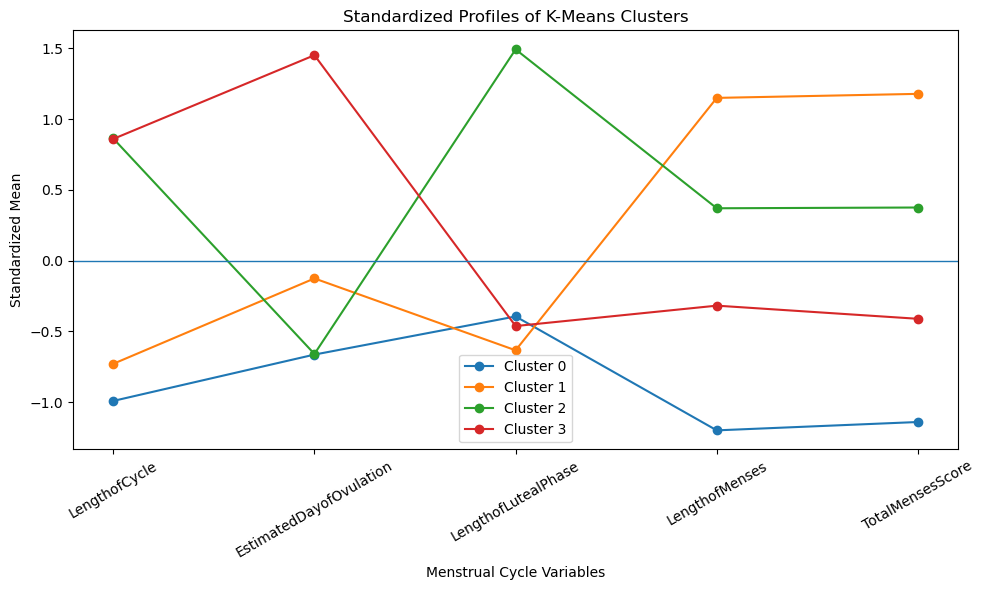

In [75]:
#Plotting the cluster-profile.
#A standardized cluster-profile plot was used to compare the relative characteristics of the four clusters across the selected menstrual variables.
plt.figure(figsize=(10, 6))

for cluster in cluster_profile_scaled.index:
    plt.plot(
        cluster_profile_scaled.columns,
        cluster_profile_scaled.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linewidth=1)
plt.title("Standardized Profiles of K-Means Clusters")
plt.xlabel("Menstrual Cycle Variables")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

plt.show()
#The main reason we're plotting a graph is because the table tells us the numbers, but the graph helps us to see the pattern.

Interpretation: 

1) Cluster 0: Below-average values across all variables, representing shorter cycles, earlier ovulation, shorter menses, and lower menses scores.
2) Cluster 1: Mainly characterized by longer menses duration and higher menses scores, while cycle and luteal-phase values remain below average.
3) Cluster 2: Characterized by longer cycles and a markedly longer luteal phase, with earlier-than-average estimated ovulation.
4) Cluster 3: Characterized by longer cycles and substantially later estimated ovulation, with slightly below-average menses and luteal-phase values.

The profiles show that the four clusters differ mainly in cycle length, ovulation timing, luteal-phase duration, and menstrual characteristics, supporting their interpretation as exploratory cycle-pattern groups.

In [77]:
#Validating the final K = 4 solution.
#Since we want the final Silhouette Score specifically for our selected K = 4 solution.
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    scaled_data,
    cluster_labels
)

print("Final Silhouette Score for K = 4:", round(final_silhouette, 3))

Final Silhouette Score for K = 4: 0.286


Interpretation: 

The final Silhouette Score of 0.286 indicates moderate-to-low cluster separation, suggesting that the identified groups overlap to some extent and should be interpreted as exploratory patterns rather than strictly distinct categories.

In [79]:
#Performing Hierarchical Clustering.
#Hierarchical clustering was applied to the same standardized dataset using four clusters to provide a secondary comparison with the K-Means results.

from sklearn.cluster import AgglomerativeClustering

#We use the same 1,512 observations and the same 5 standardized menstrual-cycle variables used for K-Means.
#This makes the comparison between the two methods fair.

hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

#Assigning each observation to one of four hierarchical clusters
hierarchical_labels = hierarchical_model.fit_predict(scaled_data)

#To display the first few cluster assignments.
hierarchical_labels[:20]

array([3, 3, 1, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 3],
      dtype=int64)

In [81]:
#Checking the cluster sizes to know whether hierarchical clustering produces balanced or highly uneven groups, just as we checked for K-Means.
#Counts the number of observations assigned to each hierarchical clustering group.

hierarchical_counts = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

hierarchical_counts

0    298
1    205
2    410
3    599
Name: count, dtype: int64

Interpretation:

1) Cluster 3 is the largest group, containing about 40% of observations.
2) Cluster 1 is the smallest, containing about 14%.
3) The groups are somewhat uneven, but there isn't an extremely tiny cluster like the K-Means Cluster 2 (86 observations).
4) This gives us a useful comparison with K-Means, where the cluster distribution was more uneven.

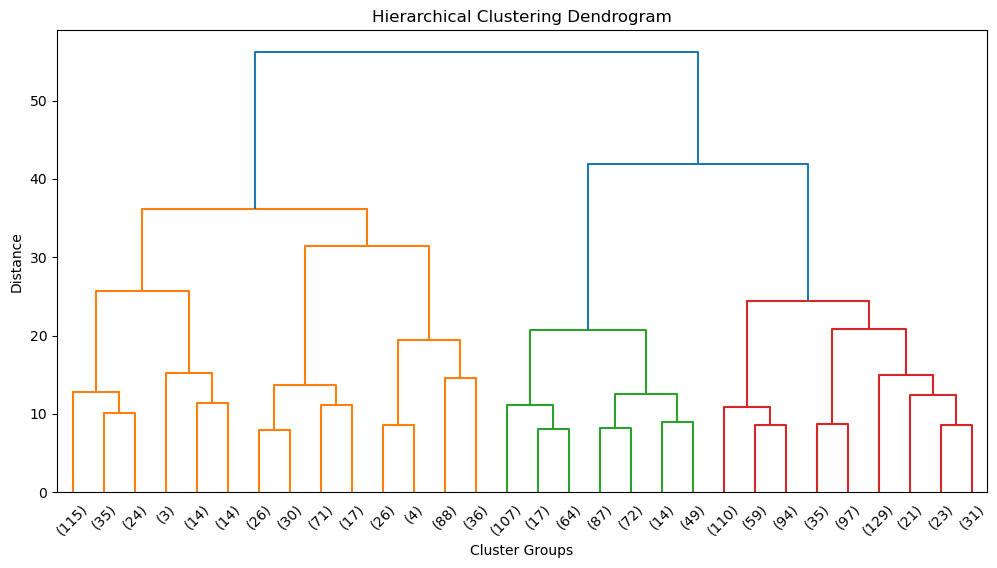

In [83]:
#Creating the dendrogram.
#Hierarchical clustering is based on progressively merging observations/groups. The dendrogram lets us visually see how those groups are formed.

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

#Creating the hierarchical linkage matrix.
#Ward linkage is consistent with the clustering method used above.

linkage_matrix = linkage(scaled_data, method="ward")

#Plotting the dendrogram.
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")

plt.show()

Interpretation: 

1) The dendrogram shows that the 1,512 observations were progressively merged according to their similarity across the five standardized menstrual-cycle variables.
2) Several smaller groups merge at relatively low distances, indicating greater similarity among those observations.
3) The larger branches merge at higher distances, suggesting that the major groups are more dissimilar from one another.
4) The visible branching structure supports the presence of distinct grouping patterns within the menstrual-cycle data.
5) However, the dendrogram alone does not establish the optimal number of clusters or biological categories; it is used alongside the K-Means and Silhouette results.
6) Therefore, the hierarchical analysis provides a secondary view of the grouping structure and can be compared with the four-cluster K-Means solution.

In [85]:
#To create theHierarchical Cluster Profiles.
#To see whether hierarchical clustering finds similar characteristics, even though its cluster labels will be different.

#Starting with the original, unscaled values used for clustering.
#Since this allows us to interpret the clusters in real units such as days and menses score.

hierarchical_data = cluster_data.copy()

#Adding the hierarchical cluster assignment.
hierarchical_data["HierarchicalCluster"] = hierarchical_labels



#To calculate the mean profile of each cluster.
hierarchical_profiles = (
    hierarchical_data
    .groupby("HierarchicalCluster")
    .mean()
)

print("Hierarchical Cluster Profiles:")
display(hierarchical_profiles)



Hierarchical Cluster Profiles:


,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,LengthofMenses,TotalMensesScore
HierarchicalCluster,,,,,
0,34.003356,20.687919,13.345638,5.976510,11.510067
1,31.590244,14.726829,16.912195,5.482927,10.258537
2,27.636585,14.668293,12.946341,3.960976,7.160976
3,27.178631,14.924875,12.222037,5.701169,10.792988


Interpretation: 

Hierarchical clustering identified four exploratory cycle-pattern groups that differed mainly in cycle length, ovulation timing, luteal phase duration, and menstrual characteristics. The resulting profiles broadly corresponded to the patterns identified through K-Means clustering.

In [87]:
#Comparing the number of observations in each clustering method.
#Putting them together to see whether both methods produce similarly balanced or highly uneven groups.

print("K-Means cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nHierarchical cluster sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

K-Means cluster sizes:
0    741
1    407
2     86
3    278
Name: count, dtype: int64

Hierarchical cluster sizes:
0    298
1    205
2    410
3    599
Name: count, dtype: int64


The two methods produced different cluster sizes, indicating differences in how the algorithms assigned observations to groups.

In [89]:
#Comparing the actual cluster assignments.
from sklearn.metrics import adjusted_rand_score

# Compare the agreement between K-Means and hierarchical clustering.
ari_score = adjusted_rand_score(
    cluster_labels,
    hierarchical_labels
)

print("Adjusted Rand Index:", ari_score)
#The Adjusted Rand Index (ARI) measures how similarly the two methods grouped the same 1,512 observations, while accounting for agreement that could occur by chance.

Adjusted Rand Index: 0.2765356743393417


Interpretation: 

The Adjusted Rand Index of 0.277 indicates limited agreement between K-Means and hierarchical clustering, suggesting that the identified groups are exploratory and partly overlapping rather than strongly separated.

In [91]:
#Creating cross-tabulation of cluster assignments.
#To see which K-Means groups correspond most strongly to which hierarchical groups.
cluster_comparison = pd.crosstab(
    pd.Series(cluster_labels, name="KMeansCluster"),
    pd.Series(hierarchical_labels, name="HierarchicalCluster")
)

print("Cluster Assignment Comparison:")
display(cluster_comparison)

Cluster Assignment Comparison:


HierarchicalCluster,0,1,2,3
KMeansCluster,,,,
0,1,73,380,287
1,92,33,0,282
2,8,78,0,0
3,197,21,30,30


The cross-tabulation showed partial correspondence between the two clustering methods, with some groups showing strong overlap while others were divided across multiple clusters.

Short summary:
So as a short summary we can say, K-Means and hierarchical clustering showed partial agreement in the grouping of menstrual-cycle observations. The Adjusted Rand Index (ARI) of 0.277 indicates limited agreement between the two clustering solutions, while the cross-tabulation demonstrated that some groups corresponded more closely than others. These findings support interpreting the clusters as exploratory representations of recurring menstrual-cycle patterns rather than clearly separated categories.

In [93]:
#Checking whether the dataset actually contains enough repeated observations per participant to justify our longitudinal analysis.
#We use the observations that were actually included in our clustering analysis.

#ClientID tells us which participant the cycle belongs to.
#CycleNumber tells us which cycle it is.

longitudinal_data = df.loc[cluster_data.index, 
                           ["ClientID", "CycleNumber"]].copy()

print("Number of observations used for longitudinal analysis:")
print(len(longitudinal_data))

print("\nNumber of unique participants:")
print(longitudinal_data["ClientID"].nunique())

print("\nCycles per participant:")
display(
    longitudinal_data.groupby("ClientID")["CycleNumber"]
    .count()
    .describe()
)

Number of observations used for longitudinal analysis:
1512

Number of unique participants:
157

Cycles per participant:


count    157.000000
mean       9.630573
std        6.589898
min        1.000000
25%        4.000000
50%       10.000000
75%       13.000000
max       43.000000
Name: CycleNumber, dtype: float64

In [95]:
#This analysis was performed using participant ID, cycle number, and K-Means cluster assignment to examine whether data-derived cycle profiles persisted or changed across repeated cycles.
#Starting with the observations that were used in our K-Means clustering.
longitudinal_data = df.loc[
    cluster_data.index,
    ["ClientID", "CycleNumber"]
].copy()

# Add the K-Means cluster assigned to each observation.
longitudinal_data["Cluster"] = cluster_labels

# Sort cycles in their natural order for each participant.
longitudinal_data = longitudinal_data.sort_values(
    ["ClientID", "CycleNumber"]
).reset_index(drop=True)

print("Longitudinal dataset shape:")
print(longitudinal_data.shape)

print("\nFirst few observations:")
display(longitudinal_data.head(10))

Longitudinal dataset shape:
(1512, 3)

First few observations:


,ClientID,CycleNumber,Cluster
0,nfp8020,1,1
1,nfp8020,2,1
2,nfp8020,3,0
3,nfp8020,4,0
4,nfp8020,5,0
5,nfp8020,6,1
6,nfp8020,7,0
7,nfp8020,8,0
8,nfp8020,9,0
9,nfp8020,10,0


Interpretation:

ClientID identifies the participant, while each row represents an individual menstrual cycle. Therefore, the same ClientID appears across multiple CycleNumber values. This longitudinal structure allows cycle-profile changes to be examined within participants.

In [97]:
#Identifying the consecutive cluster transitions.

#Making a copy so we don't accidentally change our main data.
transition_data = longitudinal_data.copy()

#For each participant, we'll be looking at the cluster of the previous cycle.
#shift(1) moves the previous cycle's cluster onto the current row.
transition_data["PreviousCluster"] = (
    transition_data
    .groupby("ClientID")["Cluster"]
    .shift(1)
)

# Keep only rows where a previous cycle exists.
# This automatically removes the first cycle of each participant.
transitions = transition_data.dropna(
    subset=["PreviousCluster"]
).copy()

# Convert the previous cluster back to integer
transitions["PreviousCluster"] = (
    transitions["PreviousCluster"].astype(int)
)


#Comparing the previous cluster with current cluster.

transitions["SameCluster"] = (
    transitions["PreviousCluster"] == transitions["Cluster"]
)

print("Number of consecutive cycle transitions:")
print(len(transitions))

print("\nTransitions where the cluster stayed the same:")
print(transitions["SameCluster"].sum())

print("\nTransitions where the cluster changed:")
print((~transitions["SameCluster"]).sum())

#Calculating the percentages
same_percentage = transitions["SameCluster"].mean() * 100
changed_percentage = (~transitions["SameCluster"]).mean() * 100

print(f"\nPercentage of transitions staying in the same cluster: "
      f"{same_percentage:.2f}%")

print(f"Percentage of transitions changing cluster: "
      f"{changed_percentage:.2f}%")

Number of consecutive cycle transitions:
1355

Transitions where the cluster stayed the same:
874

Transitions where the cluster changed:
481

Percentage of transitions staying in the same cluster: 64.50%
Percentage of transitions changing cluster: 35.50%


Interpretation:
Longitudinal analysis showed that 64.50% of consecutive cycle transitions remained within the same cluster, while 35.50% changed to another cluster. This suggests a degree of persistence in cycle profiles across repeated observations, while also indicating substantial cycle-to-cycle variability.

In [99]:
#Cluster Transition Matrix
#Counting how often each previous cluster transitions into each current cluster.

transition_matrix = pd.crosstab(
    transitions["PreviousCluster"],
    transitions["Cluster"]
)

print("Cluster Transition Matrix:")
display(transition_matrix)

Cluster Transition Matrix:


Cluster,0,1,2,3
PreviousCluster,,,,
0,511,73,22,65
1,84,218,20,47
2,15,25,28,6
3,72,44,8,117


Interpretation: 

The transition matrix shows that consecutive cycles frequently remained within the same cluster, with the highest persistence observed for Clusters 0 and 1. Changes between profiles occurred mainly among Clusters 0, 1, and 3, indicating both recurring patterns and cycle-to-cycle variability.

#Menstrual Cycle Characteristics:

a) Summarizing what EDA showed:

1) Most cycle lengths were concentrated around 25–30 days.
2) Estimated ovulation was mainly concentrated around the middle of the cycle, with some variation.
3) Luteal phase length was concentrated around approximately 12–14 days, with several extreme observations.
4) Menses length was mainly around 4–6 days.
5) Total menses score showed a broader distribution, with some variation between observations.

The dataset contains substantial variation in cycle characteristics, supporting the investigation of recurring cycle patterns.

#Relationships Between Variables:

b) Summarizing what correlation analysis showed:

1) LengthofCycle and EstimatedDayofOvulation: r = 0.737 → strong positive relationship.
2) LengthofMenses and TotalMensesScore: r = 0.829 → very strong positive relationship.
3) LengthofCycle and LengthofLutealPhase: r = 0.415 → moderate positive relationship.
4) EstimatedDayofOvulation and LengthofLutealPhase: r = -0.286 → weak-to-moderate negative relationship.
5) Other relationships were relatively weak.

Some menstrual characteristics are strongly related, while others provide more independent information about cycle patterns.

#Identified Cycle Profiles:

c) K-Means identified four exploratory profiles.

1) Cluster 0 - Shorter cycles, earlier ovulation, shorter menses and lower menses score
2) Cluster 1 - Shorter cycles with longer menses and highest menses score
3) Cluster 2 - Longer cycles with notably extended luteal phase
4) Cluster 3 - Longer cycles with later estimated ovulation

We then compared this structure using hierarchical clustering.

The relatively low Silhouette Score = 0.286 and ARI = 0.277 indicate that the profiles are not sharply separated and that the two clustering methods do not produce identical group assignments.

Therefore, we can describe them as exploratory cycle-pattern profiles.


#Longitudinal Findings:

d) Summarizing the points from these findings.

Among 1,355 consecutive cycle transitions:

1) 874 (64.50%) remained in the same cluster.
2) 481 (35.50%) changed to another cluster.

The transition matrix showed that changes occurred particularly among Clusters 0, 1, and 3.

Overall, the analysis indicates that menstrual cycle observations exhibit recurring but overlapping patterns across cycle length, ovulation timing, luteal phase, and menstrual characteristics. Four exploratory profiles were identified using K-Means clustering, with longitudinal analysis suggesting that these profiles demonstrate both persistence and variability across repeated cycles. The findings support the use of data-driven pattern analysis to characterize menstrual cycle variability, while the moderate cluster separation and methodological limitations require the identified profiles to be interpreted cautiously rather than as clinically distinct categories.